In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"../main_code/2d/Ex4.4")
sys.path.append(r"../main_code/2d")
import generate_data2,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix1
CUDA_LAUNCH_BLOCKING=1

def single_S(y,x_left,x_right,y_below,y_upper,center,r): #单个源
    cond=(y[:,0]-center[0])**2+(y[:,1]-center[1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))*cond

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): #总源
    cond1=(y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2<=r**2
    cond2=(y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2))*cond1+0.5*np.exp(-550*((y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2))*cond2



cuda:1


In [4]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
b_x_min,b_x_max,b_y_min,b_y_max=-0.35,0.35,-0.35,0.35 #边界gamma处

num_batches_gauss=1
b_n=20
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[-0.06,0.0],[0.08,0.0]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=1

S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data2.boundary_data_circle(kk, number_gene, points_b, single_S,[],[],[],[],center_true[0],r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data2.boundary_data_circle(kk, number_gene, points_b, single_S, [],[],[],[],center_true[1], r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b0 = F_mea_b1 + F_mea_b2
F_mea_db_x10 = F_mea_db_x11 + F_mea_db_x12
F_mea_db_x20= F_mea_db_x21 + F_mea_db_x22
F=org_m.F(F_mea_b0,F_mea_db_x10,F_mea_db_x20)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


In [5]:
M=6400
af="Tanh"   #先用tanh
R_m=5
cupy_device= 1
models0 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


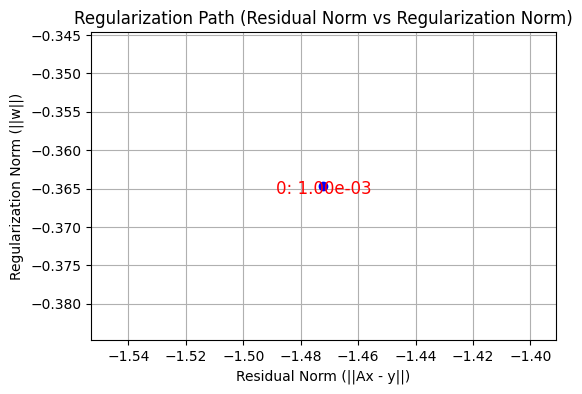

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


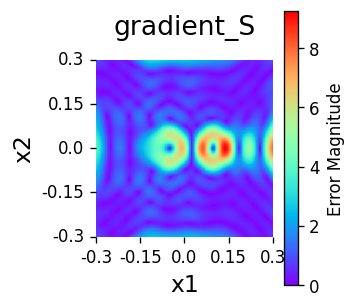

S_l_inf= 3.6861150060091994 S_L_2= 0.03162279090070201 S_l_2= 0.5087274395287584


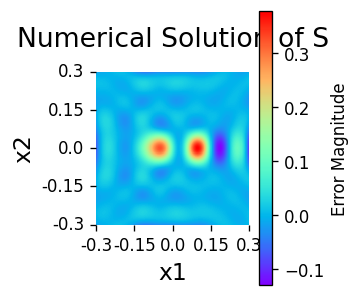

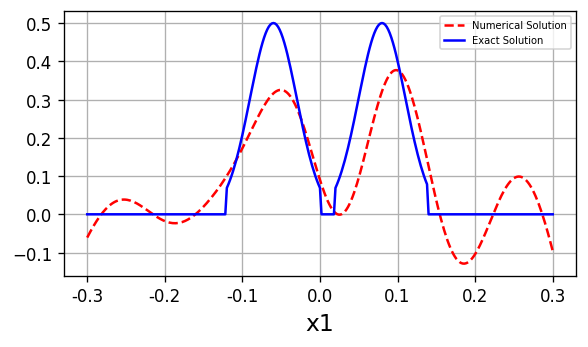

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


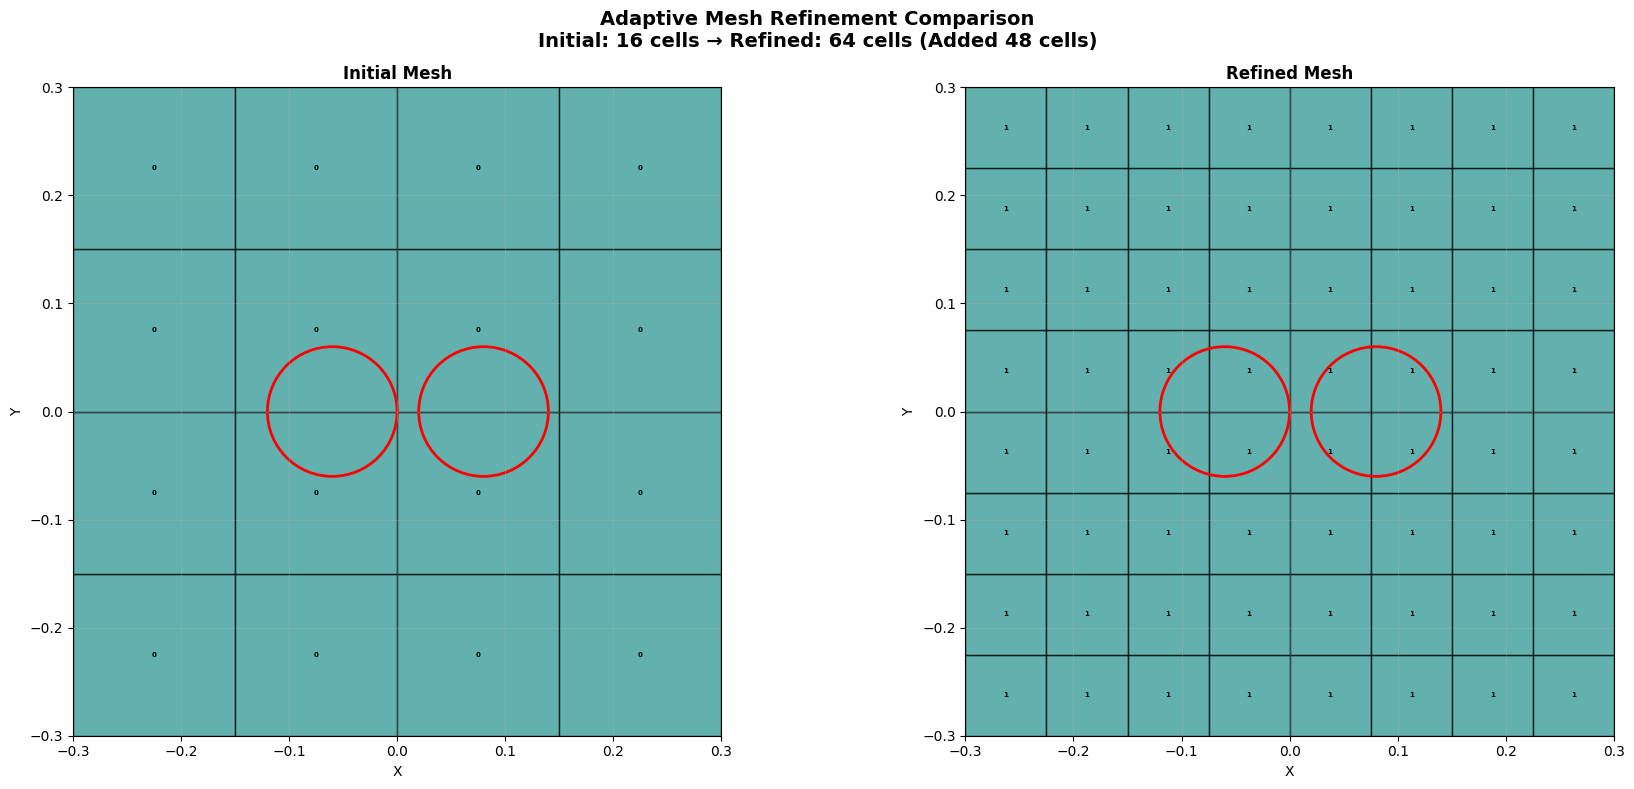

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


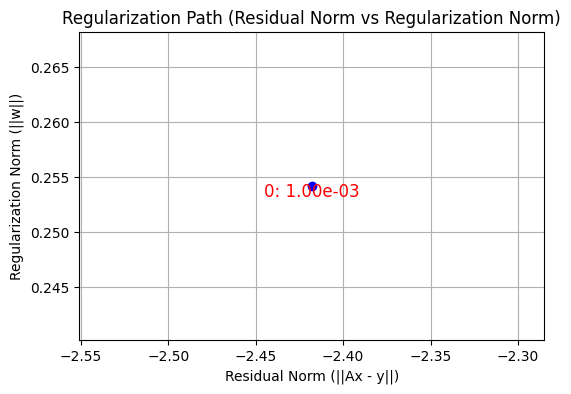

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


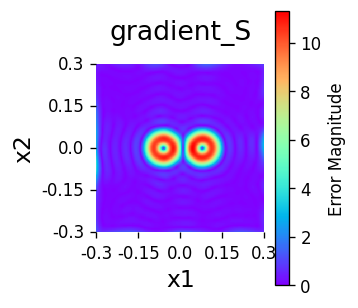

S_l_inf= 0.8430678605461783 S_L_2= 0.006120638684507304 S_l_2= 0.09846496016203762


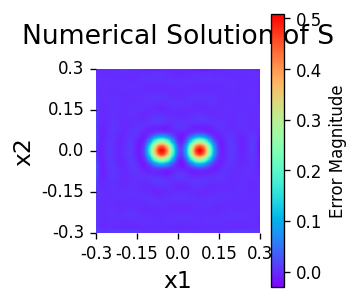

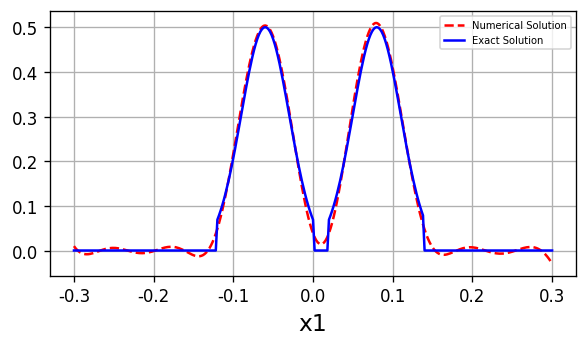

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


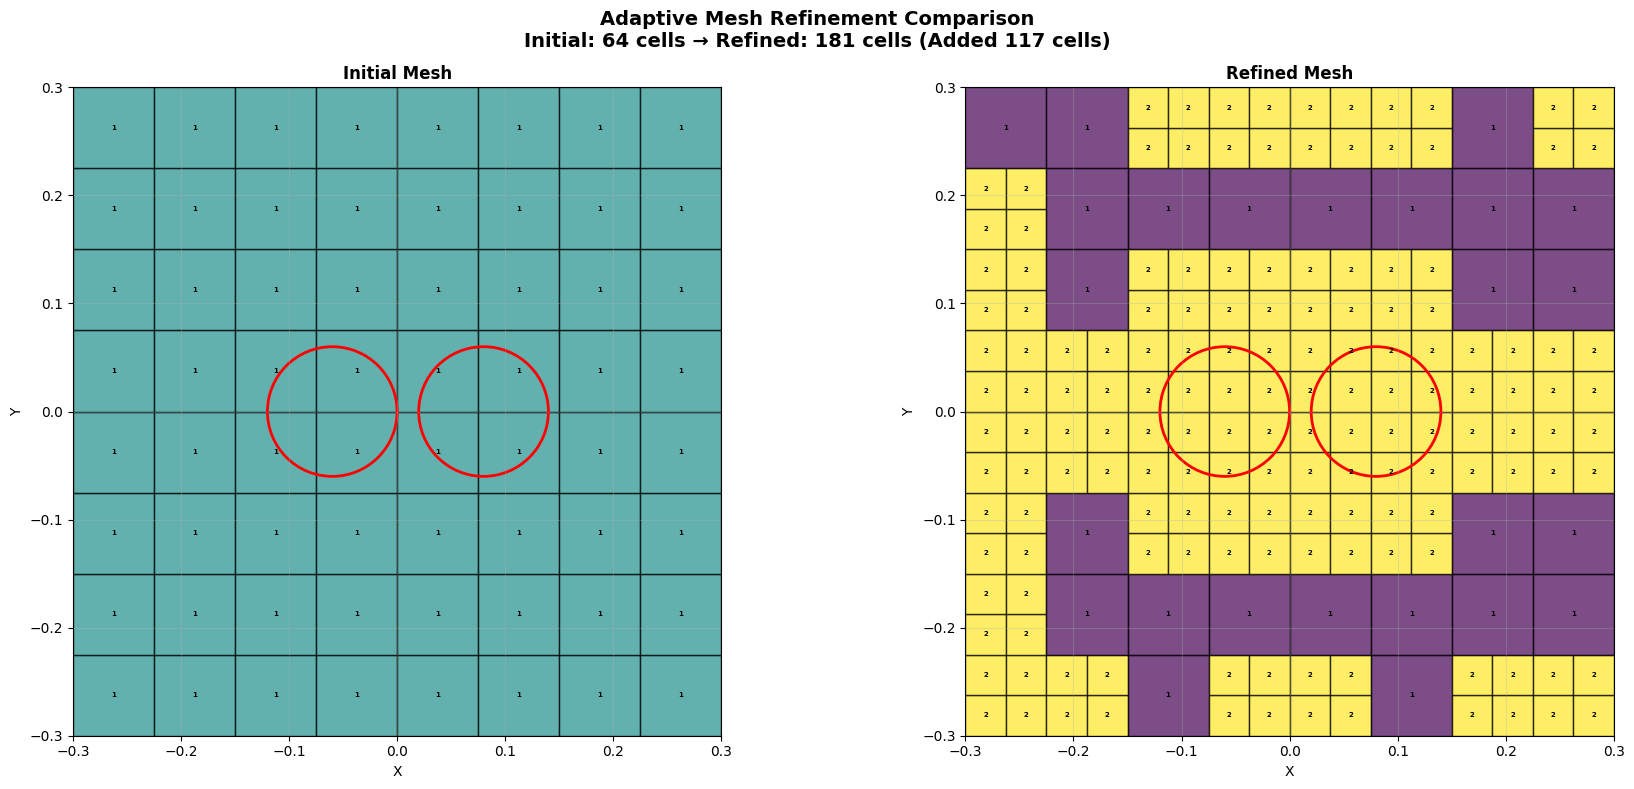

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


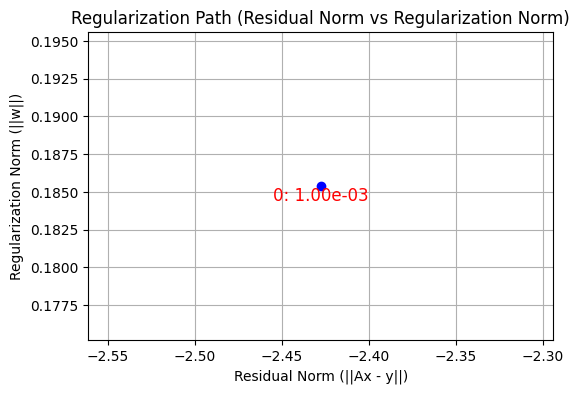

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


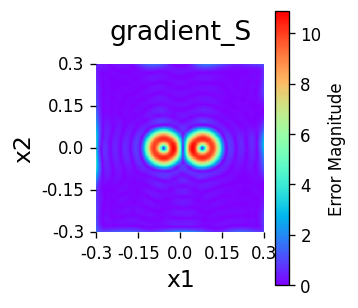

S_l_inf= 0.8743316364954424 S_L_2= 0.006073626206806844 S_l_2= 0.09770865318453023


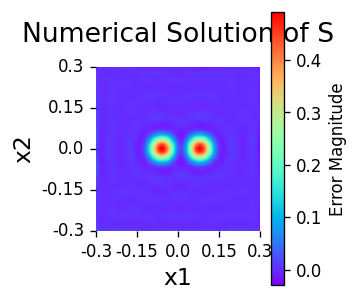

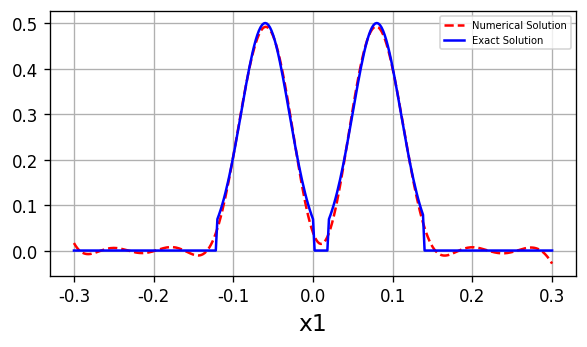

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


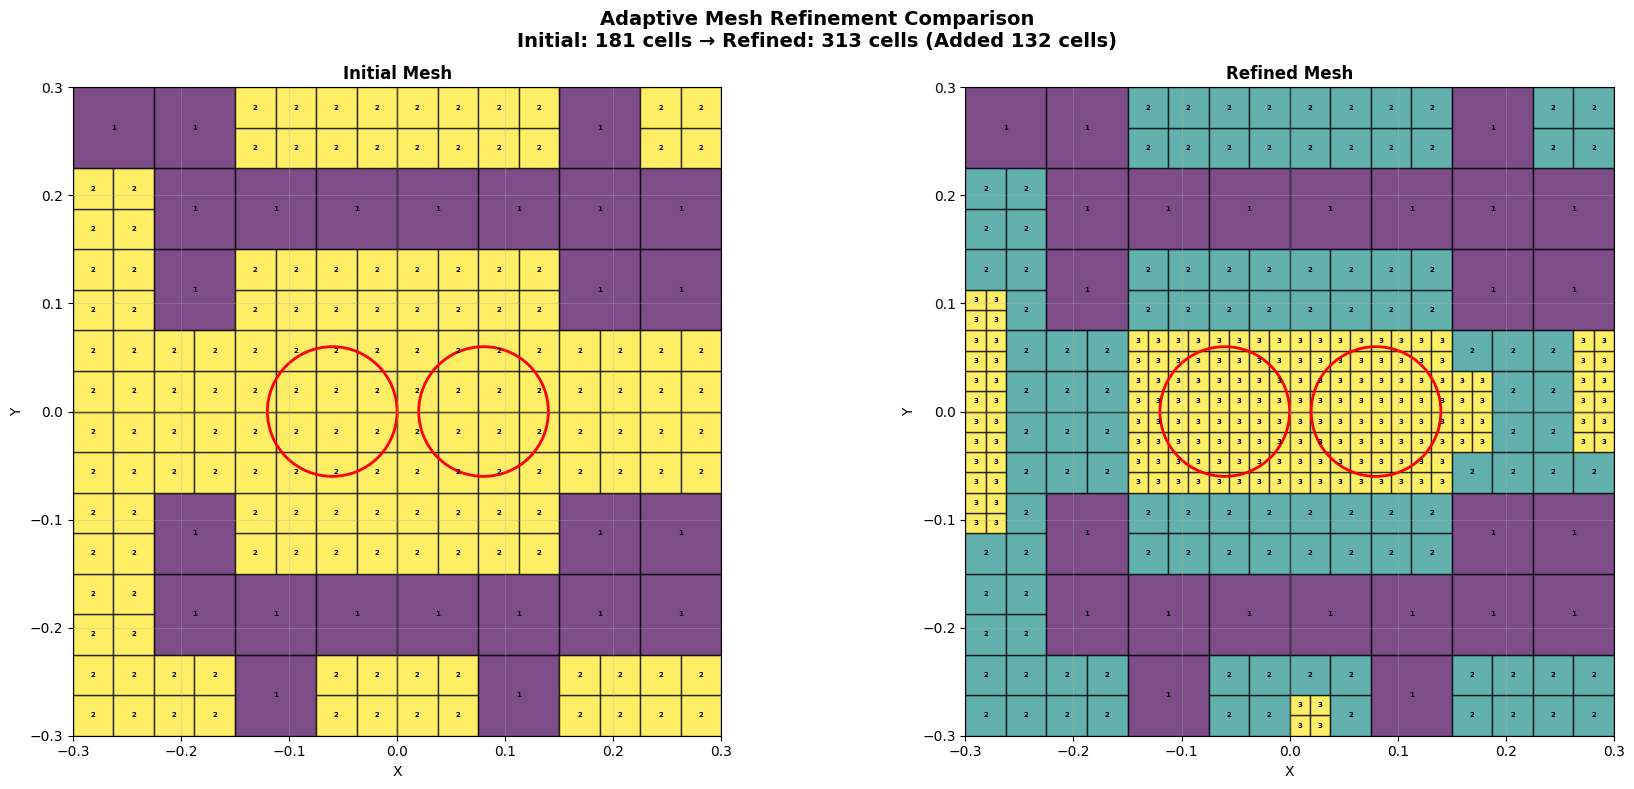

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


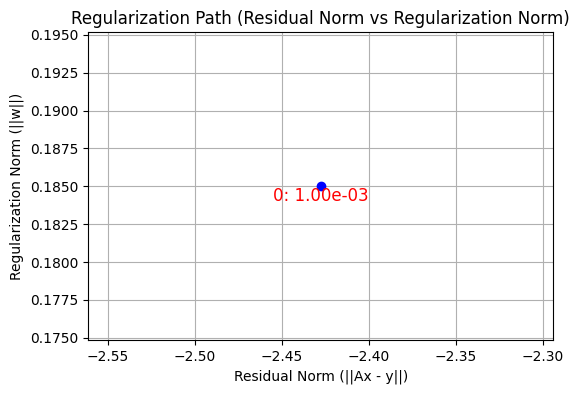

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


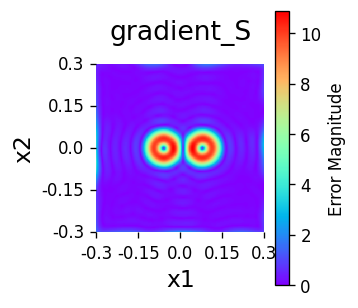

S_l_inf= 0.8742838156110793 S_L_2= 0.006075066437647107 S_l_2= 0.09773182270647401


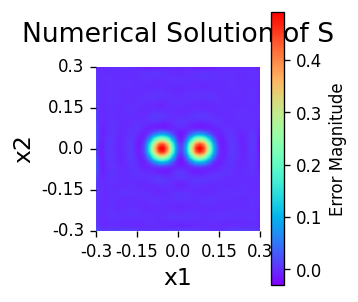

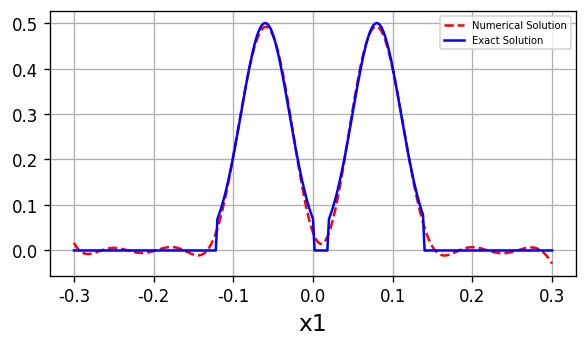

在第 3 次迭代结束


In [6]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-3,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/1000000000] * 5
refine_threshold_noise=[1/300] * 5
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main_fix1.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)